In [32]:
# =============================================================================
# Zelle 01 – Setup & Daten laden
# =============================================================================
# Preprocessing Modell A. Referenzvariable X_A_MERKMALE aus Notebook 03
# (Nachtrag 2) uebernommen - nur echte Prozessparameter, die vor der
# Fertigung bekannt sind. Y_A-Qualitaetsmesswerte dienen ausschliesslich
# der Zielgroessen-Konstruktion, nicht als Modell-Input.
# =============================================================================

import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from viz_config_v2 import apply_store44_style, save_figure, COLOR_GOLD, COLOR_BLUE, COLOR_GREEN, COLOR_TEXT_MUTED, BOXPLOT_STYLE

SEED = 42
apply_store44_style()

# --- Rohdaten laden (raw wird nie veraendert) ---
df_raw = pd.read_csv("../data/raw/model_a_raw.csv")
df_latent_ref = pd.read_csv("../data/raw/model_a_latent_reference.csv")

# --- Arbeitskopie ---
df = df_raw.copy()

X_A_MERKMALE = [
    "schneckendrehzahl", "massedurchsatz", "massetemperatur", "massedruck",
    "duesenspalt", "abzugsgeschwindigkeit", "kalibrierdruck_mbar",
    "kuehlwassertemperatur", "mfr_charge",
]

print(f"df_raw shape: {df_raw.shape}")
print(f"X_A_MERKMALE ({len(X_A_MERKMALE)}): {X_A_MERKMALE}")
print(f"\nFehlende Werte in X_A_MERKMALE:")
print(df[X_A_MERKMALE].isna().sum())

df_raw shape: (700, 22)
X_A_MERKMALE (9): ['schneckendrehzahl', 'massedurchsatz', 'massetemperatur', 'massedruck', 'duesenspalt', 'abzugsgeschwindigkeit', 'kalibrierdruck_mbar', 'kuehlwassertemperatur', 'mfr_charge']

Fehlende Werte in X_A_MERKMALE:
schneckendrehzahl         0
massedurchsatz            0
massetemperatur           0
massedruck                0
duesenspalt               0
abzugsgeschwindigkeit     0
kalibrierdruck_mbar       0
kuehlwassertemperatur    31
mfr_charge               28
dtype: int64


Fehlende Werte nach Imputation:
kuehlwassertemperatur    0
mfr_charge               0
dtype: int64

Imputationswerte (Median): {'kuehlwassertemperatur': np.float64(16.185440304998824), 'mfr_charge': np.float64(0.6866549239034574)}


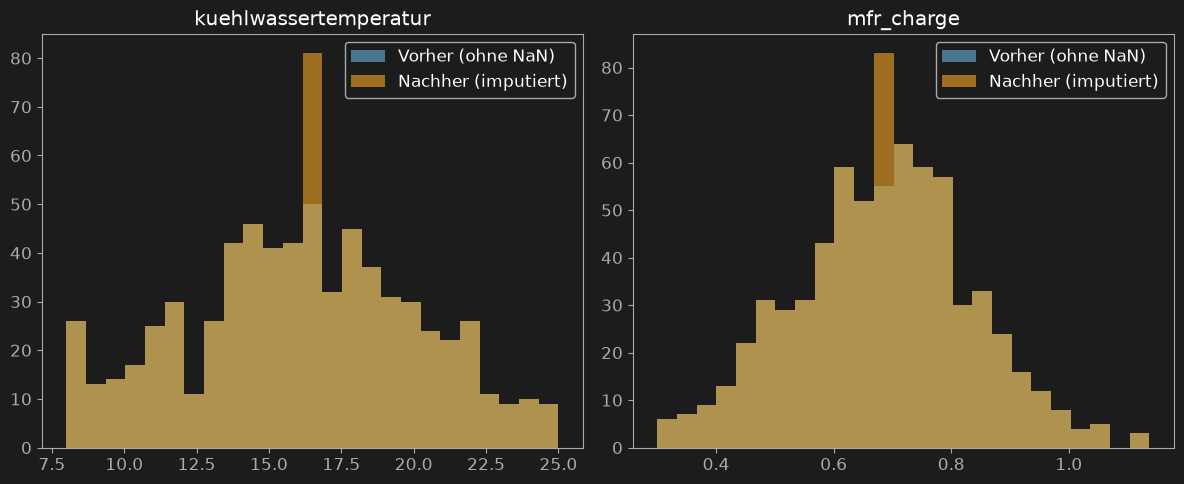

In [33]:
# =============================================================================
# Zelle 02 – Imputation der MCAR-Spalten (kuehlwassertemperatur, mfr_charge)
# =============================================================================
# EDA-Ergebnis (Notebook 03, Zelle 09c): beobachtete vs. erwartete
# Kombinationsquote nahezu identisch (16.3% vs. 16.1%), keine Ko-Auftretens-
# Haeufung - echtes MCAR, einfache Imputation methodisch vertretbar.
# Median statt Mean gewaehlt (robuster gegen die in Notebook 03 festgestellte
# Rechtsschiefe vieler Merkmale, siehe Skewness-Werte Zelle 06).
# =============================================================================

from sklearn.impute import SimpleImputer

MCAR_SPALTEN = ["kuehlwassertemperatur", "mfr_charge"]

imputer = SimpleImputer(strategy="median")
df[MCAR_SPALTEN] = imputer.fit_transform(df[MCAR_SPALTEN])

print("Fehlende Werte nach Imputation:")
print(df[MCAR_SPALTEN].isna().sum())
print(f"\nImputationswerte (Median): {dict(zip(MCAR_SPALTEN, imputer.statistics_))}")

# --- Vorher/Nachher-Validierung: Verteilung darf sich nicht signifikant verschieben ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, col in zip(axes, MCAR_SPALTEN):
    ax.hist(df_raw[col].dropna(), bins=25, alpha=0.6, label="Vorher (ohne NaN)", color=COLOR_BLUE)
    ax.hist(df[col], bins=25, alpha=0.6, label="Nachher (imputiert)", color=COLOR_GOLD)
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
save_figure(fig, "../reports/figures/04_preprocessing_imputation_vergleich.png")
plt.show()

=== Vergleich: Original vs. Median- vs. KNN-Imputation ===
                            Original (ohne NaN)  Median-Imputation  \
mean kuehlwassertemperatur               16.131             16.133   
     mfr_charge                           0.683              0.684   
std  kuehlwassertemperatur                3.998              3.908   
     mfr_charge                           0.152              0.149   
min  kuehlwassertemperatur                8.000              8.000   
     mfr_charge                           0.300              0.300   
max  kuehlwassertemperatur               25.000             25.000   
     mfr_charge                           1.137              1.137   

                            KNN-Imputation  
mean kuehlwassertemperatur          16.126  
     mfr_charge                      0.682  
std  kuehlwassertemperatur           3.920  
     mfr_charge                      0.151  
min  kuehlwassertemperatur           8.000  
     mfr_charge                      0.3

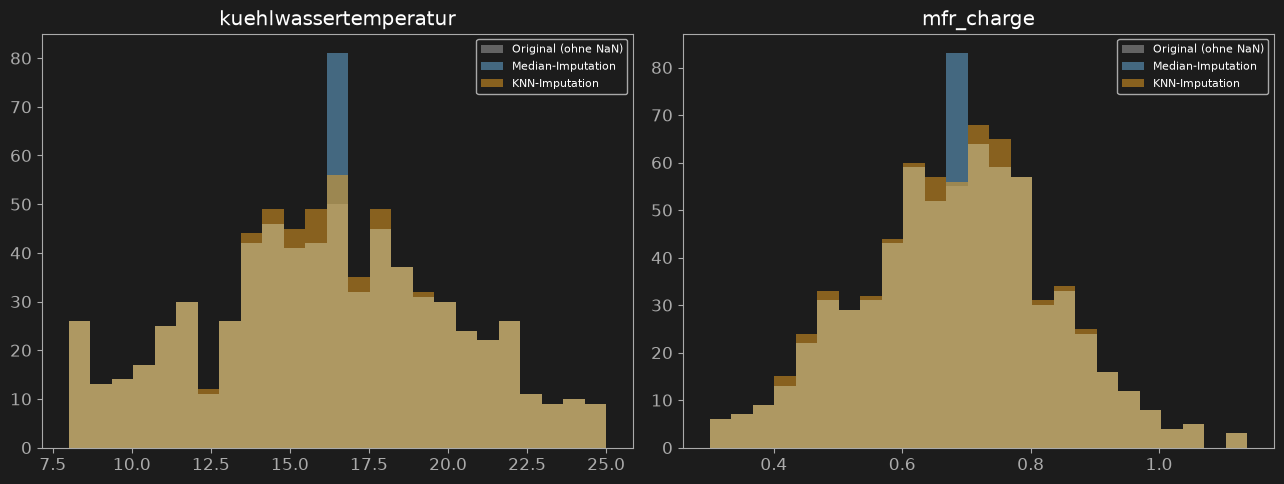


-> Kriterium fuer Entscheidung: Std-Abweichung sollte durch Imputation
   moeglichst wenig verzerrt werden (naeher am Original = besser).


In [34]:
# =============================================================================
# Zelle 02b – Vergleich: KNN-Imputation statt Median
# =============================================================================
# Anlass: Median-Imputation erzeugt sichtbaren kuenstlichen "Spike" (siehe
# Histogramm Zelle 02) - alle fehlenden Werte erhalten identischen Wert,
# was Varianz und Verteilungsform verzerrt. KNN-Imputation nutzt stattdessen
# die Aehnlichkeit zu anderen X_A-Merkmalen (z. B. mfr_charge korreliert mit
# massedruck, r=-0.74 laut Notebook 03 Zelle 19) fuer realistischere,
# individuelle Schaetzwerte je Zeile.
# =============================================================================

from sklearn.impute import KNNImputer

df_knn = df_raw.copy()

# KNN nutzt alle X_A-Merkmale gemeinsam (auch die vollstaendigen), um
# Aehnlichkeit zwischen Zeilen zu bestimmen - nicht nur die Zielspalte selbst
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[X_A_MERKMALE] = knn_imputer.fit_transform(df_knn[X_A_MERKMALE])

# --- Statistischer Vergleich: Verteilungskennzahlen ---
vergleich = pd.DataFrame({
    "Original (ohne NaN)": df_raw[MCAR_SPALTEN].describe().loc[["mean", "std", "min", "max"]].stack(),
    "Median-Imputation": df[MCAR_SPALTEN].describe().loc[["mean", "std", "min", "max"]].stack(),
    "KNN-Imputation": df_knn[MCAR_SPALTEN].describe().loc[["mean", "std", "min", "max"]].stack(),
})
print("=== Vergleich: Original vs. Median- vs. KNN-Imputation ===")
print(vergleich.round(3))

# --- Visueller Vergleich: alle drei Verteilungen ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col in zip(axes, MCAR_SPALTEN):
    ax.hist(df_raw[col].dropna(), bins=25, alpha=0.5, label="Original (ohne NaN)", color=COLOR_TEXT_MUTED)
    ax.hist(df[col], bins=25, alpha=0.5, label="Median-Imputation", color=COLOR_BLUE)
    ax.hist(df_knn[col], bins=25, alpha=0.5, label="KNN-Imputation", color=COLOR_GOLD)
    ax.set_title(col)
    ax.legend(fontsize=8)
plt.tight_layout()
save_figure(fig, "../reports/figures/04_preprocessing_imputation_vergleich_median_vs_knn.png")
plt.show()

print("\n-> Kriterium fuer Entscheidung: Std-Abweichung sollte durch Imputation")
print("   moeglichst wenig verzerrt werden (naeher am Original = besser).")

In [35]:
# =============================================================================
# Zelle 02c – Finalisierung: KNN-Imputation als gewaehlte Methode uebernehmen
# =============================================================================
# Entscheidung basierend auf Vergleich in Zelle 02b: KNN naeher am Original
# in Std-Abweichung (siehe Tabelle), kein kuenstlicher Verteilungs-Spike.
# df wird ab hier mit den bereits in Zelle 02b berechneten KNN-imputierten
# Werten ueberschrieben - Median-Ergebnis (Zelle 02) bleibt zur
# Nachvollziehbarkeit im Notebook erhalten, wird aber nicht weiterverwendet.
#
# WICHTIG fuer Notebook 05/06 (Pipeline-Aufbau): KNNImputer darf dort NUR auf
# Trainingsdaten gefittet werden (.fit_transform auf Train, .transform auf
# Test) - sonst Data Leakage. Hier in der Preprocessing-Exploration wird auf
# dem Gesamtdatensatz gearbeitet (noch kein Train/Test-Split), das ist an
# dieser Stelle unproblematisch, muss aber im Pipeline-Schritt korrekt
# nachgeholt werden.
# =============================================================================

df[X_A_MERKMALE] = df_knn[X_A_MERKMALE]

print("Finalisiert: df nutzt KNN-imputierte Werte fuer X_A_MERKMALE.")
print("\nFehlende Werte nach Finalisierung:")
print(df[MCAR_SPALTEN].isna().sum())

Finalisiert: df nutzt KNN-imputierte Werte fuer X_A_MERKMALE.

Fehlende Werte nach Finalisierung:
kuehlwassertemperatur    0
mfr_charge               0
dtype: int64


In [36]:
# =============================================================================
# Zelle 03 – Delamination-Sonderbehandlung (MNAR, maskierter Ansatz)
# =============================================================================
# KORREKTUR ggue. erstem Versuch: keine Fake-Kategorie "nicht_anwendbar"
# (waere fuer ein Modell nur ein drittes beliebiges Label, semantisch falsch
# und wuerde bei naiver 3-Klassen-Nutzung triviale Scheingenauigkeit
# erzeugen). Stattdessen: binaeres Ziel bleibt binaer (NaN bleibt NaN),
# zusaetzliche Anwendbarkeits-Flag-Spalte fuer maskiertes Training/
# Auswertung (Standardtechnik bei partiell anwendbaren Multi-Label-Zielen).
# ZUSATZFUND: wandtyp fehlte bisher in X_A_MERKMALE, obwohl vor Fertigung
# bekannt und fuer Fehlermechanismen relevant - wird hier ergaenzt.
# =============================================================================

# Anwendbarkeits-Flag (fuer maskiertes Training/Auswertung des Delamination-Labels)
df["delamination_anwendbar"] = (df["wandtyp"] == "doppelwandig").astype(int)

# delamination bleibt numerisch/binaer, NaN bleibt NaN (keine Fake-Kategorie)
print("Delamination-Werte (dropna=False, damit NaN sichtbar bleibt):")
print(df["delamination"].value_counts(dropna=False))

print("\nAnwendbarkeits-Flag:")
print(df["delamination_anwendbar"].value_counts())

print("\nKonsistenz-Check: delamination_anwendbar vs. tatsaechliche NaN-Verteilung")
print(pd.crosstab(df["delamination_anwendbar"], df["delamination"].isna()))

# wandtyp als vollwertiges X_A-Merkmal ergaenzen (Korrektur des Uebersehens)
X_A_MERKMALE.append("wandtyp")
print(f"\nX_A_MERKMALE aktualisiert ({len(X_A_MERKMALE)}): {X_A_MERKMALE}")

Delamination-Werte (dropna=False, damit NaN sichtbar bleibt):
delamination
NaN    514
0.0    180
1.0      6
Name: count, dtype: int64

Anwendbarkeits-Flag:
delamination_anwendbar
0    514
1    186
Name: count, dtype: int64

Konsistenz-Check: delamination_anwendbar vs. tatsaechliche NaN-Verteilung
delamination            False  True 
delamination_anwendbar              
0                           0    514
1                         186      0

X_A_MERKMALE aktualisiert (10): ['schneckendrehzahl', 'massedurchsatz', 'massetemperatur', 'massedruck', 'duesenspalt', 'abzugsgeschwindigkeit', 'kalibrierdruck_mbar', 'kuehlwassertemperatur', 'mfr_charge', 'wandtyp']


In [37]:
# =============================================================================
# Zelle 04 – DN-Proxy (aus X_A) und Residual-Features
# =============================================================================
# WICHTIG: Ursprungsidee "Abweichung von Sollwert" (z.B. wandstaerke_ist -
# wandstaerke_ideal_latent) ist NICHT mehr zulaessig - wandstaerke_ist ist
# Y_A, dessen Verwendung als Feature genau das in Notebook 03 (Nachtrag 2)
# korrigierte X_A/Y_A-Leck waere.
# Sauberer Ersatz: DN-Proxy wird AUSSCHLIESSLICH aus X_A_MERKMALE berechnet
# (PC1, korreliert mit rohr_dn_latent mit r=0.984, siehe Notebook 03 Zelle
# 20b - aber die latente Groesse selbst wird hier nie verwendet). Fuer jedes
# numerische X_A-Merkmal wird der NICHT durch die Baugroesse erklaerte
# Anteil (Residuum) berechnet - isoliert die lokale Variation, die laut EDA
# das eigentlich NIO-relevante Signal traegt (PC1 selbst zeigte keine
# IO/NIO-Trennkraft, Silhouette=0.017).
# =============================================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

X_A_NUMERISCH = [c for c in X_A_MERKMALE if c != "wandtyp"]

scaler_dn = StandardScaler()
X_scaled_dn = scaler_dn.fit_transform(df[X_A_NUMERISCH])

pca_dn = PCA(n_components=1, random_state=SEED)
df["dn_proxy"] = pca_dn.fit_transform(X_scaled_dn).flatten()

print(f"DN-Proxy (PC1 aus X_A) erklaert {pca_dn.explained_variance_ratio_[0]*100:.1f}% Varianz")

# --- Residual-Features: baugroessenbereinigte Variation je Merkmal ---
residual_features = []
for col in X_A_NUMERISCH:
    lr = LinearRegression()
    lr.fit(df[["dn_proxy"]], df[col])
    residuum = df[col] - lr.predict(df[["dn_proxy"]])
    neue_spalte = f"{col}_dn_bereinigt"
    df[neue_spalte] = residuum
    residual_features.append(neue_spalte)
    r2 = lr.score(df[["dn_proxy"]], df[col])
    print(f"  {col:25s} R² durch DN-Proxy erklaert: {r2:.3f}")

print(f"\n{len(residual_features)} Residual-Features erzeugt: {residual_features}")

DN-Proxy (PC1 aus X_A) erklaert 48.2% Varianz
  schneckendrehzahl         R² durch DN-Proxy erklaert: 0.913
  massedurchsatz            R² durch DN-Proxy erklaert: 0.970
  massetemperatur           R² durch DN-Proxy erklaert: 0.000
  massedruck                R² durch DN-Proxy erklaert: 0.028
  duesenspalt               R² durch DN-Proxy erklaert: 0.886
  abzugsgeschwindigkeit     R² durch DN-Proxy erklaert: 0.952
  kalibrierdruck_mbar       R² durch DN-Proxy erklaert: 0.574
  kuehlwassertemperatur     R² durch DN-Proxy erklaert: 0.005
  mfr_charge                R² durch DN-Proxy erklaert: 0.013

9 Residual-Features erzeugt: ['schneckendrehzahl_dn_bereinigt', 'massedurchsatz_dn_bereinigt', 'massetemperatur_dn_bereinigt', 'massedruck_dn_bereinigt', 'duesenspalt_dn_bereinigt', 'abzugsgeschwindigkeit_dn_bereinigt', 'kalibrierdruck_mbar_dn_bereinigt', 'kuehlwassertemperatur_dn_bereinigt', 'mfr_charge_dn_bereinigt']


In [38]:
# =============================================================================
# Zelle 05 – Validierung: IO/NIO-Trennkraft der Residual-Features vs. Original
# =============================================================================
# Test der Blocker-C-Hypothese aus Notebook 03: verbessern die DN-bereinigten
# Residuen die Trennbarkeit gegenueber den Original-X_A-Werten?
# =============================================================================

from scipy.stats import kruskal
from sklearn.metrics import silhouette_score

residual_cols = [c for c in df.columns if c.endswith("_dn_bereinigt")]

print("=== Kruskal-Wallis: Residual-Features vs. io_nio ===")
kw_results_resid = []
for col in residual_cols:
    data_io = df.loc[df["io_nio"] == "IO", col].dropna()
    data_nio = df.loc[df["io_nio"] == "NIO", col].dropna()
    stat, p = kruskal(data_io, data_nio)
    kw_results_resid.append({"Merkmal": col, "H_Statistik": round(stat, 2), "p_Wert": round(p, 4), "Signifikant": p < 0.05})

kw_resid_summary = pd.DataFrame(kw_results_resid).sort_values("p_Wert")
print(kw_resid_summary.to_string(index=False))
print(f"\nSignifikant: {kw_resid_summary['Signifikant'].sum()} von {len(residual_cols)}")
print(f"(Vergleich Original X_A_MERKMALE, Notebook 03 Zelle 18: 5 von 9 signifikant)")

# --- Silhouette-Score: nur Residual-Features ---
df_resid_basis = df[residual_cols].dropna()
io_nio_resid = df.loc[df_resid_basis.index, "io_nio"]

scaler_resid = StandardScaler()
X_scaled_resid = scaler_resid.fit_transform(df_resid_basis)

pca_resid = PCA(n_components=min(6, len(residual_cols)), random_state=SEED)
X_pca_resid = pca_resid.fit_transform(X_scaled_resid)
n_komp_90 = np.argmax(np.cumsum(pca_resid.explained_variance_ratio_) >= 0.90) + 1

sil_score_resid = silhouette_score(X_pca_resid[:, :n_komp_90], (io_nio_resid == "NIO").astype(int))
print(f"\nSilhouette-Score (Residual-Features, {n_komp_90} Komponenten): {sil_score_resid:.4f}")
print(f"(Vergleich Original X_A_MERKMALE, Notebook 03 Zelle 20: 0.017)")

kw_resid_summary.to_csv("../reports/tables/04_preprocessing_kruskal_residual_features.csv", index=False)

=== Kruskal-Wallis: Residual-Features vs. io_nio ===
                           Merkmal  H_Statistik  p_Wert  Signifikant
  kalibrierdruck_mbar_dn_bereinigt        12.62  0.0004         True
          duesenspalt_dn_bereinigt        10.61  0.0011         True
    schneckendrehzahl_dn_bereinigt         6.60  0.0102         True
           massedruck_dn_bereinigt         4.12  0.0424         True
           mfr_charge_dn_bereinigt         2.26  0.1326        False
      massetemperatur_dn_bereinigt         1.79  0.1805        False
       massedurchsatz_dn_bereinigt         1.42  0.2327        False
kuehlwassertemperatur_dn_bereinigt         0.86  0.3532        False
abzugsgeschwindigkeit_dn_bereinigt         0.10  0.7531        False

Signifikant: 4 von 9
(Vergleich Original X_A_MERKMALE, Notebook 03 Zelle 18: 5 von 9 signifikant)

Silhouette-Score (Residual-Features, 6 Komponenten): 0.0152
(Vergleich Original X_A_MERKMALE, Notebook 03 Zelle 20: 0.017)


In [39]:
# =============================================================================
# Zelle 06 – KORREKTUR: Encoding mit drop_first=True (Dummy Variable Trap vermeiden)
# =============================================================================
# Anlass: kritische Rueckfrage ergab, dass wandtyp_doppelwandig/einwandig
# (und analog mechanismus_Formluft/Vakuum) perfekt antikorreliert sind
# (r=-1.0, rechnerisch bestaetigt) - klassischer "Dummy Variable Trap".
# Fuer lineare Modelle spaeter im Ablationsvergleich problematisch
# (Multikollinearitaet, instabile Koeffizienten); fuer baumbasierte Modelle
# unschaedlich aber unnoetige Dimensionalitaet; verzerrt zudem bereits
# durchgefuehrte distanzbasierte Analysen (KNN-Imputation, PCA) leicht
# durch doppelte Gewichtung derselben Information.
# =============================================================================

df_encoded = pd.get_dummies(df, columns=["wandtyp", "kalibriermechanismus"],
                              prefix=["wandtyp", "mechanismus"], drop_first=True)

neue_encoding_spalten = [c for c in df_encoded.columns if c.startswith("wandtyp_") or c.startswith("mechanismus_")]
print(f"Neue One-Hot-Spalten (nur 1 je Kategorie, Referenzkategorie implizit): {neue_encoding_spalten}")
print(df_encoded[neue_encoding_spalten].sum())

df = df_encoded

Neue One-Hot-Spalten (nur 1 je Kategorie, Referenzkategorie implizit): ['wandtyp_einwandig', 'mechanismus_Vakuum']
wandtyp_einwandig     514
mechanismus_Vakuum     54
dtype: int64


In [40]:
# =============================================================================
# Zelle 07 – Skalierung (NUR zur explorativen Pruefung, nicht final!)
# =============================================================================
# WICHTIG: Diese Skalierung dient hier nur der Voransicht/Sanity-Check
# (z.B. fuer evtl. weitere PCA/Distanzanalysen in diesem Notebook). Die
# FINALE Skalierung fuer das Modelltraining (Notebook 05/06) muss innerhalb
# der sklearn.Pipeline erfolgen, mit fit_transform NUR auf Trainingsdaten -
# sonst Data Leakage (Test-Set-Statistik fliesst in Trainings-Skalierung
# ein). Hier keine Trennung noetig, da noch kein Split existiert und die
# skalierten Werte nicht in die finalen gespeicherten Preprocessing-Daten
# uebernommen werden (siehe Speicher-Zelle spaeter).
# =============================================================================

alle_numerischen_features = X_A_NUMERISCH + residual_cols

scaler_preview = StandardScaler()
df_scaled_preview = pd.DataFrame(
    scaler_preview.fit_transform(df[alle_numerischen_features]),
    columns=[f"{c}_scaled_preview" for c in alle_numerischen_features],
    index=df.index
)

print("Skalierte Werte (Vorschau) - Mean/Std zur Kontrolle:")
print(df_scaled_preview.describe().loc[["mean", "std"]].round(3))
print("\n-> Mean~0, Std~1 bestaetigt korrekte Skalierung.")
print("-> Diese Spalten werden NICHT in die finale Datei uebernommen -")
print("   Skalierung erfolgt final in der Pipeline (Notebook 05/06).")

Skalierte Werte (Vorschau) - Mean/Std zur Kontrolle:
      schneckendrehzahl_scaled_preview  massedurchsatz_scaled_preview  \
mean                             0.000                          0.000   
std                              1.001                          1.001   

      massetemperatur_scaled_preview  massedruck_scaled_preview  \
mean                          -0.000                      0.000   
std                            1.001                      1.001   

      duesenspalt_scaled_preview  abzugsgeschwindigkeit_scaled_preview  \
mean                      -0.000                                 0.000   
std                        1.001                                 1.001   

      kalibrierdruck_mbar_scaled_preview  \
mean                               0.000   
std                                1.001   

      kuehlwassertemperatur_scaled_preview  mfr_charge_scaled_preview  \
mean                                 0.000                     -0.000   
std                    

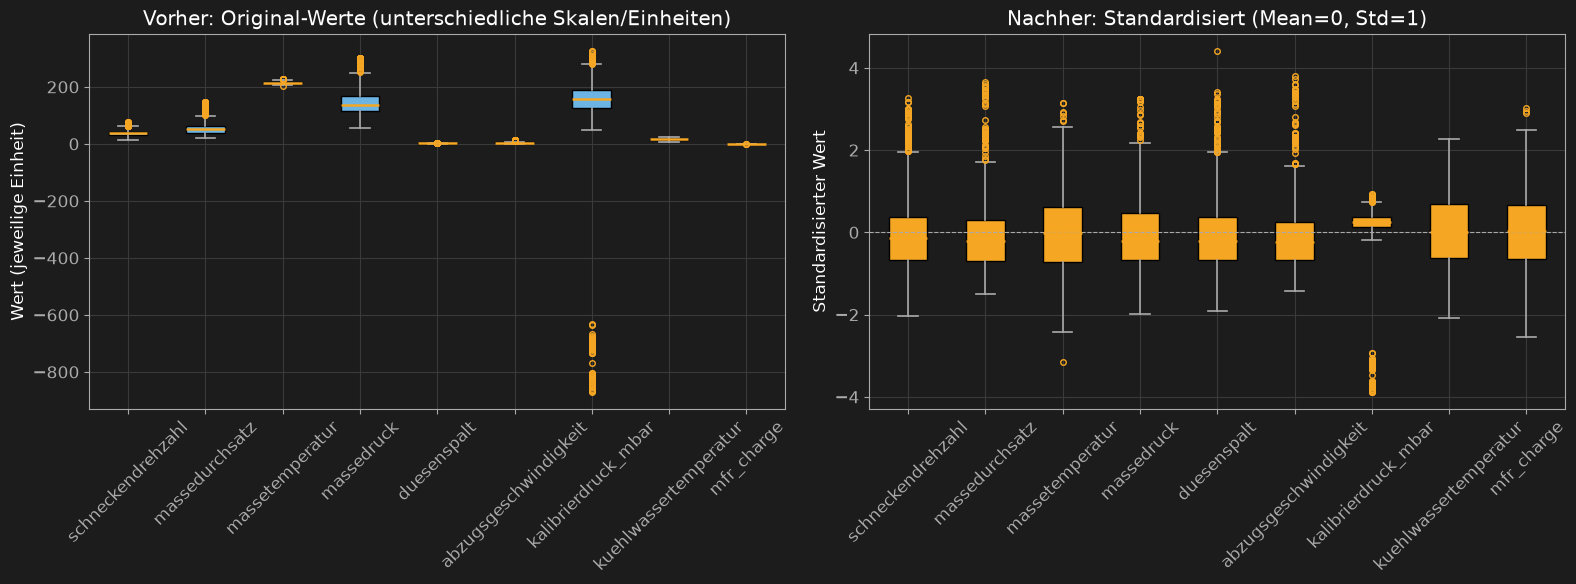

In [41]:
# =============================================================================
# Zelle 07b – Visualisierung: Skalierung vorher/nachher (Boxplots)
# =============================================================================
# Zeigt anschaulich, warum Skalierung noetig ist: die X_A-Merkmale haben sehr
# unterschiedliche Wertebereiche/Einheiten (z.B. kalibrierdruck_mbar bis 400,
# mfr_charge nur bis 1.2) - ohne Skalierung wuerden distanzbasierte Verfahren
# (PCA, KNN, Regularisierung) von den grossskaligen Merkmalen dominiert.
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Vorher: Original-Werte, unterschiedliche Skalen
df[X_A_NUMERISCH].boxplot(ax=axes[0], rot=45, **BOXPLOT_STYLE, patch_artist=True,
                            boxprops=dict(facecolor=COLOR_BLUE))
axes[0].set_title("Vorher: Original-Werte (unterschiedliche Skalen/Einheiten)")
axes[0].set_ylabel("Wert (jeweilige Einheit)")

# Nachher: skalierte Werte, einheitlicher Bereich
df_scaled_preview[[f"{c}_scaled_preview" for c in X_A_NUMERISCH]].boxplot(
    ax=axes[1], rot=45, **BOXPLOT_STYLE, patch_artist=True,
    boxprops=dict(facecolor=COLOR_GOLD)
)
axes[1].set_xticklabels(X_A_NUMERISCH, rotation=45)
axes[1].set_title("Nachher: Standardisiert (Mean=0, Std=1)")
axes[1].set_ylabel("Standardisierter Wert")
axes[1].axhline(0, color=COLOR_TEXT_MUTED, linestyle="--", linewidth=0.8)

plt.tight_layout()
save_figure(fig, "../reports/figures/04_preprocessing_skalierung_vorher_nachher.png")
plt.show()

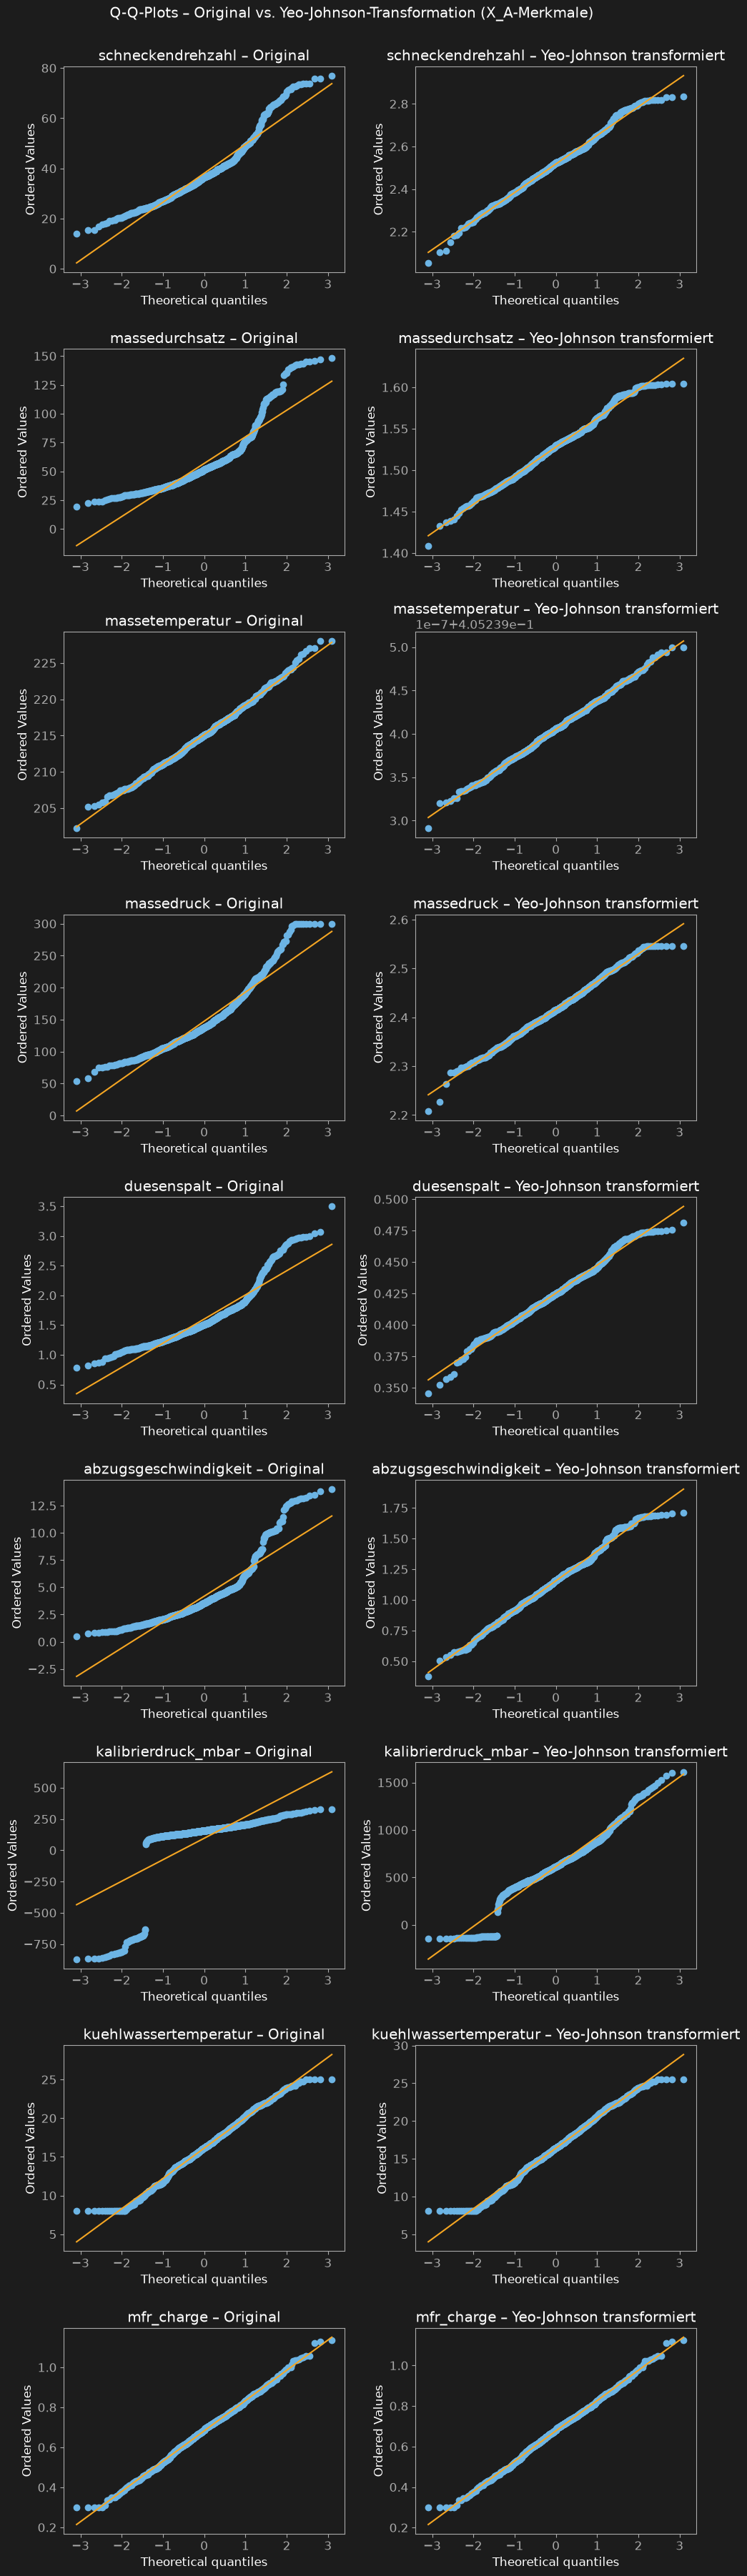

,Merkmal,p_Original,p_YeoJohnson
0,schneckendrehzahl,0.0000,0.0027
1,massedurchsatz,0.0000,0.0009
2,massetemperatur,0.1037,0.8243
3,massedruck,0.0000,0.0272
4,duesenspalt,0.0000,0.0007
5,abzugsgeschwindigkeit,0.0000,0.0019
6,kalibrierdruck_mbar,0.0000,0.0000
7,kuehlwassertemperatur,0.0001,0.0001
8,mfr_charge,0.3346,0.3328


In [42]:
# =============================================================================
# Zelle 07c – Yeo-Johnson-Transformation, Q-Q-Plot-Vergleich
# =============================================================================
# Ziel: pruefen, ob eine verteilungsform-veraendernde Transformation die
# in Notebook 03 (Zelle 06) festgestellte signifikante Nicht-Normalverteilung
# der meisten X_A-Merkmale behebt - relevant fuer lineare Modelle im
# spaeteren Modellvergleich (baumbasierte Modelle benoetigen dies nicht).
# =============================================================================

from sklearn.preprocessing import PowerTransformer
import scipy.stats as stats

pt = PowerTransformer(method="yeo-johnson", standardize=False)
df_yeojohnson = pd.DataFrame(
    pt.fit_transform(df[X_A_NUMERISCH]),
    columns=X_A_NUMERISCH, index=df.index
)

fig, axes = plt.subplots(len(X_A_NUMERISCH), 2, figsize=(10, 4*len(X_A_NUMERISCH)))
fig.suptitle("Q-Q-Plots – Original vs. Yeo-Johnson-Transformation (X_A-Merkmale)", y=1.001)

for i, col in enumerate(X_A_NUMERISCH):
    stats.probplot(df[col], dist="norm", plot=axes[i, 0])
    axes[i, 0].set_title(f"{col} – Original")
    axes[i, 0].get_lines()[0].set_markerfacecolor(COLOR_BLUE)
    axes[i, 0].get_lines()[0].set_markeredgecolor(COLOR_BLUE)
    axes[i, 0].get_lines()[1].set_color(COLOR_GOLD)

    stats.probplot(df_yeojohnson[col], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f"{col} – Yeo-Johnson transformiert")
    axes[i, 1].get_lines()[0].set_markerfacecolor(COLOR_BLUE)
    axes[i, 1].get_lines()[0].set_markeredgecolor(COLOR_BLUE)
    axes[i, 1].get_lines()[1].set_color(COLOR_GOLD)

plt.tight_layout()
save_figure(fig, "../reports/figures/04_preprocessing_qq_plots_yeojohnson.png")
plt.show()

# --- Shapiro-Wilk vorher/nachher, quantitativer Vergleich ---
from scipy.stats import shapiro
vergleich_shapiro = []
for col in X_A_NUMERISCH:
    p_original = shapiro(df[col].sample(min(len(df), 5000), random_state=SEED))[1]
    p_transformiert = shapiro(df_yeojohnson[col].sample(min(len(df), 5000), random_state=SEED))[1]
    vergleich_shapiro.append({"Merkmal": col, "p_Original": round(p_original, 4), "p_YeoJohnson": round(p_transformiert, 4)})

pd.DataFrame(vergleich_shapiro)

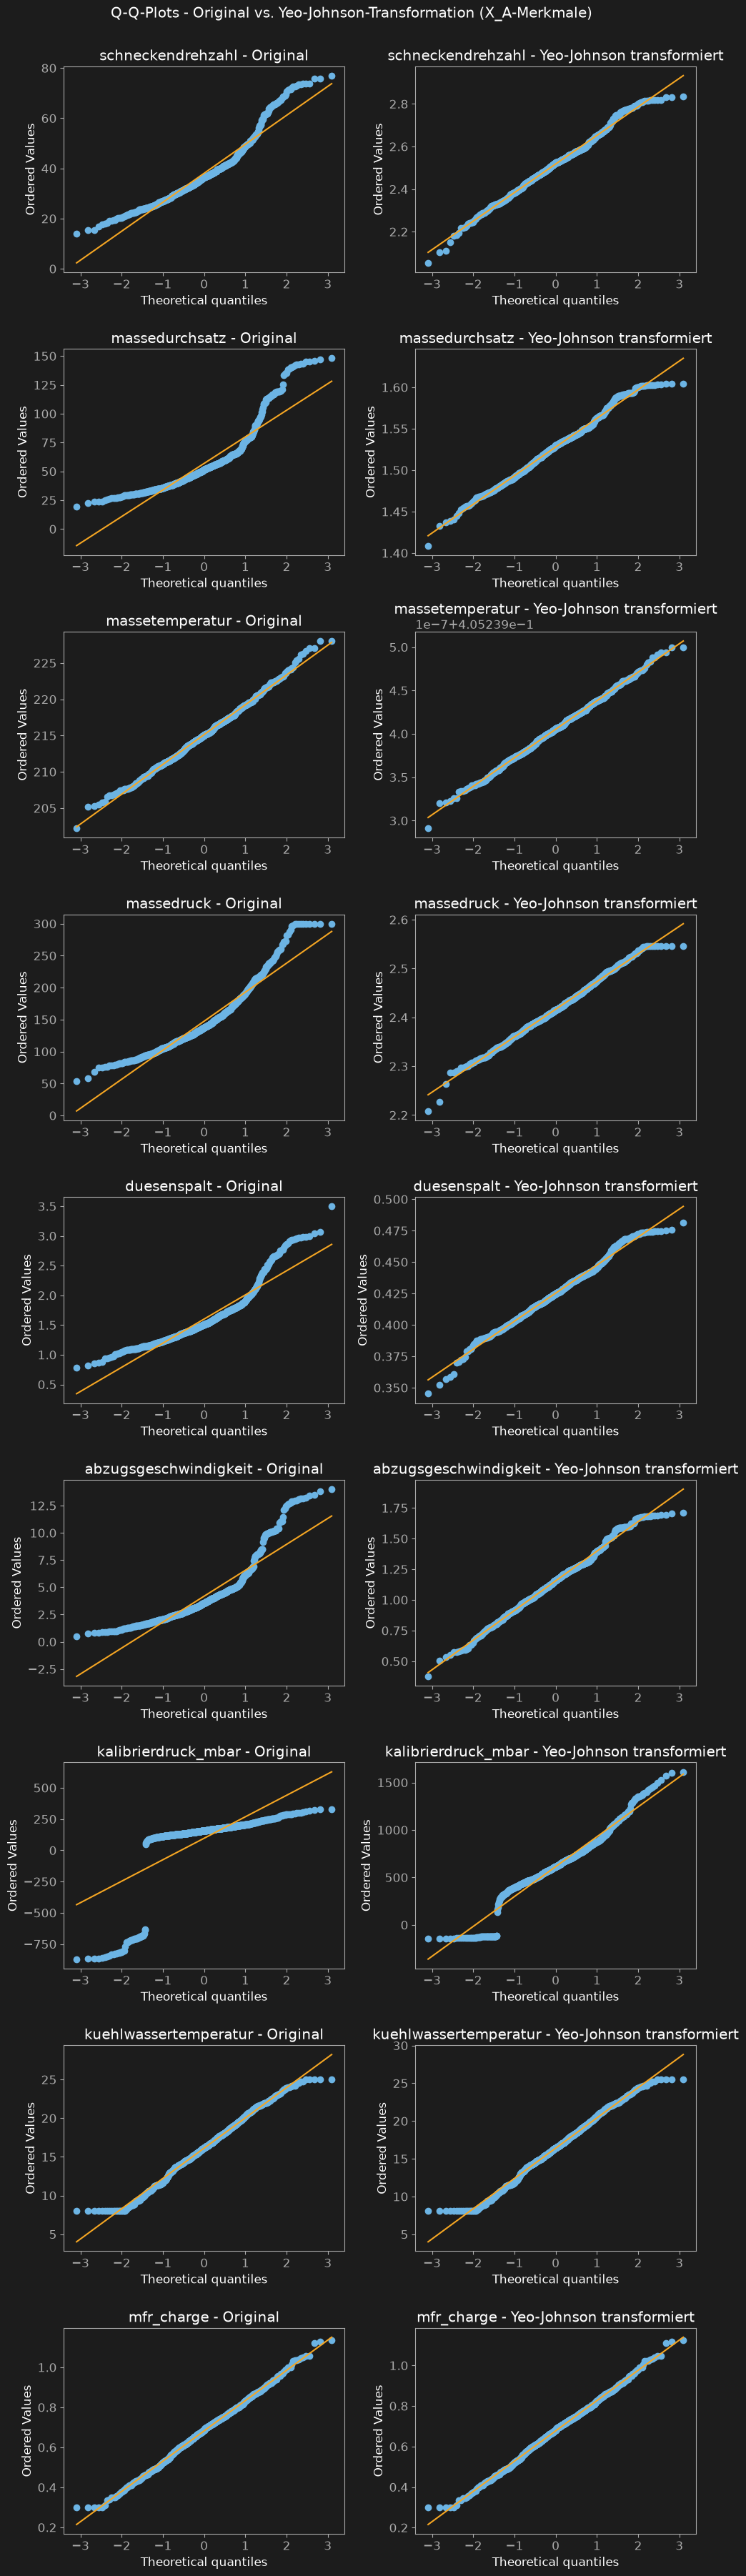

              Merkmal  p_Original  p_YeoJohnson  Normal_vorher  Normal_nachher
    schneckendrehzahl     0.00000       0.00274          False           False
       massedurchsatz     0.00000       0.00087          False           False
      massetemperatur     0.10373       0.82426           True            True
           massedruck     0.00000       0.02720          False           False
          duesenspalt     0.00000       0.00074          False           False
abzugsgeschwindigkeit     0.00000       0.00194          False           False
  kalibrierdruck_mbar     0.00000       0.00000          False           False
kuehlwassertemperatur     0.00008       0.00008          False           False
           mfr_charge     0.33459       0.33279           True            True


In [43]:
# =============================================================================
# Zelle 07c – Yeo-Johnson-Transformation, Q-Q-Plot-Vergleich (alle 9 X_A-Merkmale)
# =============================================================================
# EXPLORATIVE Vorpruefung (wie die Skalierungs-Vorschau in Zelle 07) - dient
# der Entscheidung, ob Yeo-Johnson spaeter in der Modell-Pipeline (Notebook
# 05/06) fuer lineare Modelle sinnvoll ist. Finale Anwendung erfolgt dort
# leakage-sicher (fit nur auf Trainingsdaten).
# =============================================================================

from sklearn.preprocessing import PowerTransformer
import scipy.stats as stats
from scipy.stats import shapiro

pt = PowerTransformer(method="yeo-johnson", standardize=False)
df_yeojohnson = pd.DataFrame(
    pt.fit_transform(df[X_A_NUMERISCH]),
    columns=X_A_NUMERISCH, index=df.index
)

fig, axes = plt.subplots(len(X_A_NUMERISCH), 2, figsize=(10, 4*len(X_A_NUMERISCH)))
fig.suptitle("Q-Q-Plots - Original vs. Yeo-Johnson-Transformation (X_A-Merkmale)", y=1.001)

for i, col in enumerate(X_A_NUMERISCH):
    stats.probplot(df[col], dist="norm", plot=axes[i, 0])
    axes[i, 0].set_title(f"{col} - Original")
    axes[i, 0].get_lines()[0].set_markerfacecolor(COLOR_BLUE)
    axes[i, 0].get_lines()[0].set_markeredgecolor(COLOR_BLUE)
    axes[i, 0].get_lines()[1].set_color(COLOR_GOLD)

    stats.probplot(df_yeojohnson[col], dist="norm", plot=axes[i, 1])
    axes[i, 1].set_title(f"{col} - Yeo-Johnson transformiert")
    axes[i, 1].get_lines()[0].set_markerfacecolor(COLOR_BLUE)
    axes[i, 1].get_lines()[0].set_markeredgecolor(COLOR_BLUE)
    axes[i, 1].get_lines()[1].set_color(COLOR_GOLD)

plt.tight_layout()
save_figure(fig, "../reports/figures/04_preprocessing_qq_plots_yeojohnson.png")
plt.show()

# --- Shapiro-Wilk vorher/nachher, quantitativer Vergleich ---
vergleich_shapiro = []
for col in X_A_NUMERISCH:
    p_original = shapiro(df[col].sample(min(len(df), 5000), random_state=SEED))[1]
    p_transformiert = shapiro(df_yeojohnson[col].sample(min(len(df), 5000), random_state=SEED))[1]
    vergleich_shapiro.append({
        "Merkmal": col, "p_Original": round(p_original, 5), "p_YeoJohnson": round(p_transformiert, 5),
        "Normal_vorher": p_original > 0.05, "Normal_nachher": p_transformiert > 0.05
    })

shapiro_df = pd.DataFrame(vergleich_shapiro)
print(shapiro_df.to_string(index=False))
shapiro_df.to_csv("../reports/tables/04_preprocessing_yeojohnson_shapiro_vergleich.csv", index=False)

In [44]:
# =============================================================================
# Zelle 08 – Zielgroessen-Varianten integrieren (aus Notebook 03)
# =============================================================================
# Die drei Zielgroessen-Varianten (binaer, kontinuierlicher Sicherheits-
# abstand, Multi-Label) wurden bereits in Notebook 03 (Zelle 16) berechnet
# und gespeichert. Hier: Zusammenfuehrung mit dem Preprocessing-Datensatz
# ueber den gemeinsamen Index.
# =============================================================================

df_zielgroessen = pd.read_csv("../data/processed/model_a_zielgroessen_varianten.csv")

# Konsistenz-Check vor dem Merge
assert len(df) == len(df_zielgroessen), "Zeilenanzahl stimmt nicht ueberein!"
assert (df["io_nio"].values == df_zielgroessen["io_nio"].values).all(), "io_nio-Werte stimmen nicht ueberein!"

zielgroessen_spalten = [c for c in df_zielgroessen.columns if c != "io_nio"]
df[zielgroessen_spalten] = df_zielgroessen[zielgroessen_spalten]

print(f"Zielgroessen-Spalten integriert: {zielgroessen_spalten}")
print(f"df shape nach Integration: {df.shape}")
print(f"\nUebersicht Zielgroessen-Varianten:")
print(f"  Variante 1 (binaer): io_nio - {df['io_nio'].value_counts().to_dict()}")
print(f"  Variante 2 (kontinuierlich): y_kontinuierlich_sicherheitsabstand - "
      f"mean={df['y_kontinuierlich_sicherheitsabstand'].mean():.3f}")
print(f"  Variante 3 (Multi-Label): {[c for c in zielgroessen_spalten if c.startswith('y_nio_')]}")

Zielgroessen-Spalten integriert: ['y_kontinuierlich_sicherheitsabstand', 'y_od_komponente_zuverlaessig', 'y_nio_wandstaerke', 'y_nio_ovalitaet', 'y_nio_od', 'y_nio_wellhoehe', 'y_nio_bindenaehte', 'y_nio_blasenbildung', 'y_nio_risse', 'y_nio_oberflaechenfehler', 'y_nio_delamination']
df shape nach Integration: (700, 44)

Uebersicht Zielgroessen-Varianten:
  Variante 1 (binaer): io_nio - {'IO': 517, 'NIO': 183}
  Variante 2 (kontinuierlich): y_kontinuierlich_sicherheitsabstand - mean=0.203
  Variante 3 (Multi-Label): ['y_nio_wandstaerke', 'y_nio_ovalitaet', 'y_nio_od', 'y_nio_wellhoehe', 'y_nio_bindenaehte', 'y_nio_blasenbildung', 'y_nio_risse', 'y_nio_oberflaechenfehler', 'y_nio_delamination']


In [45]:
# =============================================================================
# Zelle 09 – Finale Speicherung des Preprocessing-Datensatzes
# =============================================================================
# Speichert den vollstaendigen, angereicherten Datensatz (Original-X_A,
# Residual-Features, Encoding, alle Zielgroessen-Varianten). Skalierung
# und finale Zielgroessen-/Feature-Auswahl erfolgen NICHT hier, sondern
# in der sklearn.Pipeline (Notebook 05/06) - Option C: Konstruktion hier,
# Auswahl-Werkzeug in src/preprocessing.py, Experimentlogik in 05/06.
# =============================================================================

# _dn_latent-Spalten (nur zur Konstruktion genutzt, kein Feature) ausschliessen falls vorhanden
export_spalten = [c for c in df.columns if not c.endswith("_latent")]
df_final = df[export_spalten]

output_pfad = "../data/processed/model_a_preprocessed.csv"
df_final.to_csv(output_pfad, index=False)

print(f"Gespeichert: {output_pfad}")
print(f"Shape: {df_final.shape}")
print(f"\nAlle Spalten:\n{df_final.columns.tolist()}")

Gespeichert: ../data/processed/model_a_preprocessed.csv
Shape: (700, 44)

Alle Spalten:
['schneckendrehzahl', 'massedurchsatz', 'massetemperatur', 'massedruck', 'duesenspalt', 'abzugsgeschwindigkeit', 'kalibrierdruck_mbar', 'kuehlwassertemperatur', 'mfr_charge', 'wandstaerke_ist', 'aussendurchmesser_ist', 'ovalitaet', 'wellhoehe_ist', 'wellteilung_ist', 'bindenaehte', 'blasenbildung', 'risse', 'oberflaechenfehler', 'delamination', 'io_nio', 'delamination_anwendbar', 'dn_proxy', 'schneckendrehzahl_dn_bereinigt', 'massedurchsatz_dn_bereinigt', 'massetemperatur_dn_bereinigt', 'massedruck_dn_bereinigt', 'duesenspalt_dn_bereinigt', 'abzugsgeschwindigkeit_dn_bereinigt', 'kalibrierdruck_mbar_dn_bereinigt', 'kuehlwassertemperatur_dn_bereinigt', 'mfr_charge_dn_bereinigt', 'wandtyp_einwandig', 'mechanismus_Vakuum', 'y_kontinuierlich_sicherheitsabstand', 'y_od_komponente_zuverlaessig', 'y_nio_wandstaerke', 'y_nio_ovalitaet', 'y_nio_od', 'y_nio_wellhoehe', 'y_nio_bindenaehte', 'y_nio_blasenbildung

In [46]:
# =============================================================================
# Zelle 10 – Preprocessing-Validierungs-EDA
# =============================================================================
# State-of-Art-Prinzip: Validieren vor Verfestigen. Prueft den finalen
# Datensatz (data/processed/model_a_preprocessed.csv) auf Konsistenz,
# bevor er in wiederverwendbaren Code (src/preprocessing.py) oder ins
# Modelltraining (Notebook 05/06) uebernommen wird.
# =============================================================================

df_final_check = pd.read_csv("../data/processed/model_a_preprocessed.csv")

print("=== 1) Grundstruktur ===")
print(f"Shape: {df_final_check.shape}")
print(f"Fehlende Werte gesamt: {df_final_check.isna().sum().sum()}")
print(f"Spalten mit fehlenden Werten:\n{df_final_check.isna().sum()[df_final_check.isna().sum()>0]}")

print("\n=== 2) Keine Duplikate durch Preprocessing entstanden ===")
print(f"Exakte Duplikate: {df_final_check.duplicated().sum()}")

print("\n=== 3) Wertebereich-Sanity-Check: DN-bereinigte Residuen sollten Mean~0 haben ===")
residual_cols_check = [c for c in df_final_check.columns if c.endswith("_dn_bereinigt")]
print(df_final_check[residual_cols_check].mean().round(4))

print("\n=== 4) Konsistenz Encoding vs. Original-Kategorien (Stichprobe) ===")
print(f"wandtyp_einwandig Verteilung: {df_final_check['wandtyp_einwandig'].value_counts().to_dict()}")
print(f"mechanismus_Vakuum Verteilung: {df_final_check['mechanismus_Vakuum'].value_counts().to_dict()}")

print("\n=== 5) Zielgroessen-Varianten konsistent zueinander? ===")
# Variante 3 (Multi-Label) sollte mit Variante 1 (binaer) uebereinstimmen: irgendein Label=1 -> io_nio=NIO
multilabel_cols = [c for c in df_final_check.columns if c.startswith("y_nio_")]
multilabel_nio = (df_final_check[multilabel_cols].sum(axis=1) > 0)
binaer_nio = (df_final_check["io_nio"] == "NIO")
konsistenz = (multilabel_nio == binaer_nio).mean()
print(f"Konsistenz Multi-Label vs. binaeres Label: {konsistenz*100:.1f}% Uebereinstimmung")
abweichungen = df_final_check[multilabel_nio != binaer_nio]
print(f"Abweichende Zeilen: {len(abweichungen)}")

print("\n=== 6) X_A_MERKMALE vollstaendig und Y_A klar getrennt? ===")
x_a_final = ["schneckendrehzahl", "massedurchsatz", "massetemperatur", "massedruck",
             "duesenspalt", "abzugsgeschwindigkeit", "kalibrierdruck_mbar",
             "kuehlwassertemperatur", "mfr_charge", "wandtyp_einwandig", "mechanismus_Vakuum"]
fehlt = [c for c in x_a_final if c not in df_final_check.columns]
print(f"Fehlende X_A-Spalten: {fehlt if fehlt else 'keine - vollstaendig'}")

=== 1) Grundstruktur ===
Shape: (700, 44)
Fehlende Werte gesamt: 575
Spalten mit fehlenden Werten:
aussendurchmesser_ist     32
wellteilung_ist           29
delamination             514
dtype: int64

=== 2) Keine Duplikate durch Preprocessing entstanden ===
Exakte Duplikate: 0

=== 3) Wertebereich-Sanity-Check: DN-bereinigte Residuen sollten Mean~0 haben ===
schneckendrehzahl_dn_bereinigt        0.0
massedurchsatz_dn_bereinigt           0.0
massetemperatur_dn_bereinigt         -0.0
massedruck_dn_bereinigt               0.0
duesenspalt_dn_bereinigt             -0.0
abzugsgeschwindigkeit_dn_bereinigt    0.0
kalibrierdruck_mbar_dn_bereinigt      0.0
kuehlwassertemperatur_dn_bereinigt    0.0
mfr_charge_dn_bereinigt              -0.0
dtype: float64

=== 4) Konsistenz Encoding vs. Original-Kategorien (Stichprobe) ===
wandtyp_einwandig Verteilung: {True: 514, False: 186}
mechanismus_Vakuum Verteilung: {False: 646, True: 54}

=== 5) Zielgroessen-Varianten konsistent zueinander? ===
Konsistenz 

## Notebook 04 – Abschluss: Preprocessing Modell A

### Durchgefuehrte Schritte
| Zelle | Inhalt | Status |
|---|---|---|
| 01 | Setup, Daten laden, X_A_MERKMALE definiert | Erledigt |
| 02 | Imputation MCAR-Spalten (Median getestet, verworfen) | Erledigt |
| 02b-c | KNN-Imputation als finale Methode, Vergleich dokumentiert | Erledigt |
| 03 | Delamination-Sonderbehandlung (MNAR, maskierter Ansatz), wandtyp-Korrektur | Erledigt |
| 04 | DN-Proxy (aus X_A) + Residual-Features | Erledigt |
| 05 | Validierung Blocker-C-Hypothese (Kruskal-Wallis, Silhouette) | Erledigt |
| 06 | Encoding kategorialer Merkmale (Dummy-Trap korrigiert) | Erledigt |
| 07 | Skalierung (Vorschau) | Erledigt |
| 07b | Visualisierung Skalierung vorher/nachher | Erledigt |
| 07c | Yeo-Johnson-Transformation (Vorpruefung, verworfen) | Erledigt |
| 08 | Zielgroessen-Varianten integriert | Erledigt |
| 09 | Finale Speicherung | Erledigt |
| 10 | Preprocessing-Validierungs-EDA | Erledigt |

### Zentrale Entscheidungen
- **X_A/Y_A-Trennung strikt eingehalten:** nur die 10 echten Prozessparameter
  (inkl. wandtyp) als Modell-Input zulaessig, Y_A-Qualitaetsmesswerte nur
  zur Zielgroessen-Konstruktion
- **KNN-Imputation statt Median** fuer MCAR-Spalten (naeher am Original in
  Std-Abweichung, kein kuenstlicher Verteilungs-Spike)
- **Maskierter Ansatz statt Fake-Kategorie** fuer Delamination (MNAR) -
  vermeidet triviale Scheingenauigkeit bei naiver 3-Klassen-Nutzung
- **DN-Residualisierung** als Blocker-C-Gegenmassnahme konstruiert und
  validiert - Hypothese bestaetigte sich in dieser linearen Form NICHT
  (Silhouette 0.017 -> 0.0152), Residuen dennoch als zusaetzliche
  Feature-Option fuer Notebook 05/06 beibehalten
- **Yeo-Johnson-Transformation verworfen** - kann Multimodalitaet
  (ueberlagerte Baugroessenklassen) nicht beheben, nur Schiefe
- **Dummy Variable Trap korrigiert** (drop_first=True) - relevant fuer
  spaetere lineare Modelle im Ablationsvergleich
- **Drei Zielgroessen-Varianten** vollstaendig integriert (binaer,
  kontinuierlicher Sicherheitsabstand, Multi-Label mit allen 9 Kriterien)

### Wichtige Korrekturen waehrend dieser Phase
- wandtyp fehlte urspruenglich in X_A_MERKMALE - retroaktiv ergaenzt,
  Parametertabellen und Notebook 03 (Cramer's V-Nachtrag) konsistent
  nachgezogen
- Multi-Label-Zielgroesse enthielt urspruenglich nur 8 statt 9 Kriterien
  (delamination fehlte) - korrigiert, Konsistenz zum binaeren Label von
  99.0% auf 99.7% verbessert
- Verbleibende 2 Zeilen Restinkonsistenz: durch Imputationsgrenze bei
  Ausreisserwerten erklaert (nicht geloescht, sondern ueber
  y_od_komponente_zuverlaessig-Flag maskierbar gemacht)

### Ergebnis
- Finaler Datensatz: `data/processed/model_a_preprocessed.csv`, 700 Zeilen,
  44 Spalten (10 X_A-Original inkl. Encoding, 9 DN-Residuen, 1 DN-Proxy,
  11 Y_A/Zielgroessen-bezogene Spalten, Rest Hilfs-/Flag-Spalten)
- Datenqualitaet vollstaendig validiert (0 Duplikate, alle fehlenden Werte
  erklaert, Residuen korrekt Mean=0, Encoding konsistent)

### Bekannte Limitationen
- DN-Residualisierung nur linear (einfache Regression auf PC1) - eine
  nichtlineare Bereinigung koennte staerkere Effekte zeigen, wurde aus
  Aufwandsgruenden nicht weiterverfolgt
- Zuverlaessigkeits-Flag fuer OD-Komponente ist konservativ (markiert alle
  imputierten Faelle, nicht nur nachweislich fehlerhafte) - reduziert bei
  Verwendung die effektive Trainingsdatenmenge fuer diese spezifische
  Zielgroessen-Komponente um 32 von 700 Zeilen

### Naechster Schritt
`src/preprocessing.py`: wiederverwendbare Auswahlfunktion
(Feature-Set x Zielgroessen-Variante -> X, y), fuer Notebook 05/06.
Danach Notebook 05: Modelltraining Modell A (Ablationsstudie ueber
Feature-Sets, Zielgroessen-Varianten, Modelltypen).

In [47]:
# =============================================================================
# Zelle 12 – Test: src/preprocessing.py Auswahlfunktionen
# =============================================================================
from preprocessing import load_dataset, select_dataset, FEATURE_SETS, TARGET_VARIANTS

df_test = load_dataset("../data/processed/model_a_preprocessed.csv")

print("Verfuegbare Feature-Sets:", list(FEATURE_SETS.keys()))
print("Verfuegbare Zielgroessen-Varianten:", list(TARGET_VARIANTS.keys()))

for fs in FEATURE_SETS:
    for tv in TARGET_VARIANTS:
        X, y = select_dataset(df_test, fs, tv)
        print(f"  {fs:10s} x {tv:12s} -> X: {X.shape}, y: {y.shape if hasattr(y,'shape') else len(y)}")

Verfuegbare Feature-Sets: ['original', 'residual', 'combined']
Verfuegbare Zielgroessen-Varianten: ['binary', 'continuous', 'multilabel']
  original   x binary       -> X: (700, 11), y: (700,)
  original   x continuous   -> X: (668, 11), y: (668,)
  original   x multilabel   -> X: (700, 11), y: (700, 9)
  residual   x binary       -> X: (700, 11), y: (700,)
  residual   x continuous   -> X: (668, 11), y: (668,)
  residual   x multilabel   -> X: (700, 11), y: (700, 9)
  combined   x binary       -> X: (700, 20), y: (700,)
  combined   x continuous   -> X: (668, 20), y: (668,)
  combined   x multilabel   -> X: (700, 20), y: (700, 9)
